Alexander W. Criswell 10/21/25

Trying a longer test run with parallel tempering and broader spectral uncertainties.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import cupy as xp
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.cm
from matplotlib import patches
# import jax.numpy as jnp
# import jax; jax.config.update("jax_enable_x64", True)
from corner import corner, overplot_lines
import legwork as lw
import astropy.units as u
from tqdm import tqdm
from math import factorial

In [3]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State, BranchSupplemental
from eryn.backends import SupplementalBackend
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove, DistributionGenerate, MTDistGenMove, Move
from eryn.utils.utility import groups_from_inds
from multiprocessing import Pool

In [4]:
np.random.seed(42)

In [5]:
xp.cuda.is_available()

True

In [6]:
## set environment variables
import os
os.environ['PELARGIR_GPU'] = '1'
os.environ['SCIPY_ARRAY_API'] = '1'
os.environ['PELARGIR_ERYN'] = '1'

In [7]:
if os.environ['PELARGIR_GPU']:
    print('GPU enabled.')

GPU enabled.


In [8]:
import sys
prop_path = '/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/pelargir/'
sys.path.insert(1, prop_path)
from models import PopModel
from inference import GalacticBinaryPrior, PopulationHyperPrior
from utils import get_amp_freq, lisa_noise_psd, set_style, to_numpy
from plotting import plot_spectra, plot_spectra_flexible, plot_corners, plot_model_chains, plot_model_loglikes, plot_Nres_hist
from moves import make_PriorMove, PoissonMove
import distributions as st

GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.


In [9]:
set_style()

In [10]:
test_rng = xp.random.default_rng(170817)

In [11]:
test_prior = GalacticBinaryPrior(test_rng)

In [12]:
pop_theta = {'m_mu':xp.array([0.6]),'m_sigma':xp.array([0.15]),
             # 'd_mu':xp.array([30]),'d_sigma':xp.array([10]),
             'd_gamma_a':xp.array([4]),'d_gamma_b':xp.array([4]),
             'a_alpha':xp.array([1/2])}
test_prior.condition(pop_theta)

In [13]:
samps = test_prior.sample_conditional(int(1e7))

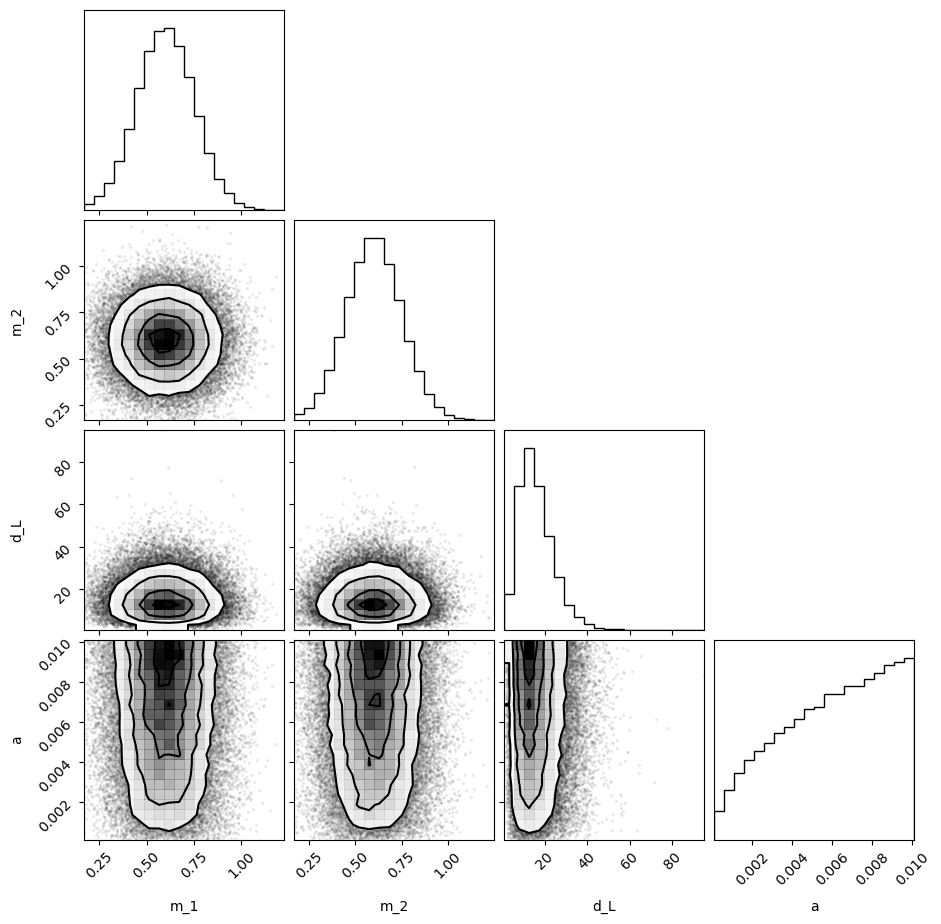

In [14]:
plt.close()
fig = corner(samps[:,::200].get().T,labels=list(test_prior.conditional_dict.keys()))
plt.show()

In [15]:
amps, fgws = get_amp_freq(samps)

In [16]:
test_hprior = PopulationHyperPrior(test_rng)

In [17]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,5e-3,test_bin_width)
test_popmodel = PopModel(1e7,test_rng,hyperprior=test_hprior,Nsamp=1,thresh_compute_frac=1.0,fbins=test_fbins)

In [18]:
test_f, test_fg, N_res = test_popmodel.run_model(pop_theta)

To compare to the initial population draw, we need to run the thresholder on it.

In [19]:
data_N_res, data_coarse_fg = test_popmodel.thresher.serial_array_sort(xp.array([fgws,amps]),
                                                                      test_popmodel.fbins,
                                                                      snr_thresh=test_popmodel.thresh_val,
                                                                      compute_frac=test_popmodel.tc_frac)
data_fg = test_popmodel.reweight_foreground(data_coarse_fg)[1:]

In [20]:
data_N_res

array(874)

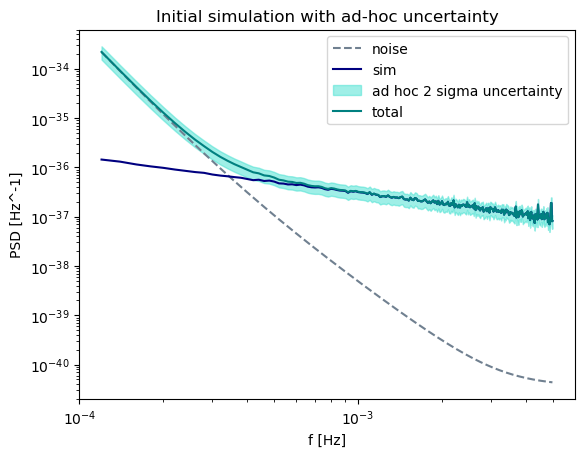

In [21]:
total_fs = test_f.get()
total_spec = data_fg.get() + lisa_noise_psd(test_f).get()
errs = 0.15*total_spec
# errs = 1e-38
plt.figure()
plt.loglog(total_fs,lisa_noise_psd(test_f).get(),c='slategrey',ls='--',label='noise')
plt.loglog(total_fs,data_fg.get(),c='navy',label='sim')
# plt.fill_between(total_fs,10**(np.log10(total_spec)-2*err),10**(np.log10(total_spec)+2*err),
#                  color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
plt.fill_between(total_fs,total_spec-2*errs,total_spec+2*errs,
                 color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
plt.loglog(total_fs,total_spec,label='total',c='teal')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('PSD [Hz^-1]')
plt.title('Initial simulation with ad-hoc uncertainty')
# plt.ylim(1e-40,1e-36)
plt.show()

In [22]:
## setup w.r.t. the data
datadict = {'fs':test_f,
            'fg':data_fg,
            'fg_sigma':xp.array(errs),
            'Nres':data_N_res,
            'noise':lisa_noise_psd(test_f)}

In [23]:
test_rng = xp.random.default_rng(42)

In [24]:
translation_dict = {0:'m_mu',
                    1:'m_sigma',
                    2:'d_gamma_a',
                    3:'d_gamma_b',
                    4:'a_alpha'}
## starting with the broader priors
eryn_hyperprior_dict = {0:st.uniform(test_rng,loc=0.4,scale=0.4,cast=True),
                        1:st.invgamma(test_rng,5,cast=True),
                        2:st.uniform(test_rng,loc=2,scale=4,cast=True), ## these are pretty arbitrary
                        3:st.uniform(test_rng,loc=2,scale=4,cast=True), ## these are pretty arbitrary
                        4:st.uniform(test_rng,0.25,0.75,cast=True)}
eryn_trans_dict = {translation_dict[key]:eryn_hyperprior_dict[key] for key in eryn_hyperprior_dict.keys()}

In [25]:
eryn_trans_dict

{'m_mu': <distributions.uniform at 0x7f09f472afc0>,
 'm_sigma': <distributions.invgamma at 0x7f09f472a210>,
 'd_gamma_a': <distributions.uniform at 0x7f09f4839ee0>,
 'd_gamma_b': <distributions.uniform at 0x7f0a000c32f0>,
 'a_alpha': <distributions.uniform at 0x7f09f47b17f0>}

In [26]:
eryn_prior = ProbDistContainer(eryn_hyperprior_dict)

In [27]:
eryn_popmodel = PopModel(1e7,test_rng,hyperprior=eryn_trans_dict,fbins=test_fbins)

In [28]:
eryn_popmodel.construct_likelihood(datadict)

In [29]:
log_like_fn = eryn_popmodel.fg_N_ln_prob

In [30]:
ndim = len(eryn_popmodel.hyperprior.hyperprior_dict)
nwalkers = 10
ntemps = 3

In [31]:
# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps)

In [32]:
## MH with prior draws as the proposal function
PriorMove = make_PriorMove(eryn_prior)
# PriorMove = DistributionGenerate({'model_0':eryn_prior})

Set up the branch supplemental to track the foreground spectra and number of resolved binaries:

In [33]:
branch_supp = BranchSupplemental(
    {"spectra": np.zeros((ntemps,nwalkers,1,len(test_f))),
     "Nres": np.zeros((ntemps,nwalkers,1,1))},
    base_shape=(ntemps, nwalkers,1),
    copy=True
)

In [34]:
# starting positions
# randomize throughout prior
coords = eryn_prior.rvs(size=(ntemps,nwalkers,))

Because we are now including the branch supplemental, we need to make a starting State object.

In [35]:
start_state = State(coords,
                    branch_supplemental={'model_0':branch_supp})

Initialize the new supplemental backend. Need to provide the supplemental names and dims.

In [36]:
supp_dims = {'spectra':(len(test_f),),
             'Nres':1}
supp_backend = SupplementalBackend(supp_dims)

Build an Eryn ensemble with the added branch supplemental and backend.

In [37]:
ensemble = EnsembleSampler(nwalkers,
                           ndim,
                           log_like_fn,
                           eryn_prior,
                           moves=[(StretchMove(),0.7),(PriorMove,0.1),(PoissonMove(),0.2)],
                           track_moves=True,
                           tempering_kwargs=tempering_kwargs,
                           provide_supplemental=True,
                           dynamic_branch_supplemental=True,
                           backend=supp_backend
                          )

In [38]:
ensemble.provide_supplemental

True

In [51]:
nsteps = 1
burn = None
thin_by = 1
out = ensemble.run_mcmc(start_state, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:12<00:00, 12.14s/it]


In [52]:
ensemble.get_chain_supplemental(temp_index=0)['model_0']['Nres'].shape

(11, 10, 1, 1)

In [56]:
ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'][-1,...]

array([[[1.72848127e-36, 1.88281124e-36, 1.65029638e-36, ...,
         7.17717940e-38, 7.12763782e-38, 6.19545395e-38]],

       [[1.75105106e-36, 1.48267816e-36, 1.29275289e-36, ...,
         4.18091290e-38, 3.11290406e-38, 4.16362713e-38]],

       [[2.59928592e-36, 2.25278915e-36, 1.97149610e-36, ...,
         1.08913047e-37, 7.18068418e-38, 1.02723371e-37]],

       ...,

       [[1.75919661e-36, 1.48352769e-36, 1.29010622e-36, ...,
         3.65663115e-38, 3.90813603e-38, 3.26496365e-38]],

       [[1.30877254e-36, 1.25100158e-36, 1.10784435e-36, ...,
         1.52604157e-37, 1.35051833e-37, 1.19335257e-37]],

       [[1.13222606e-36, 1.07657450e-36, 9.53411478e-37, ...,
         6.89009467e-38, 9.28574809e-38, 9.00349951e-38]]])

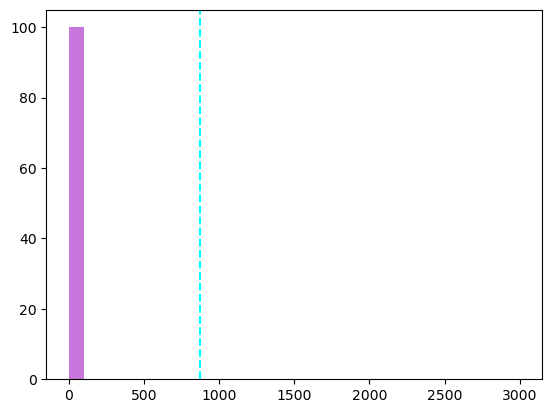

In [41]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),temp_index=0)#,showtrue=False)

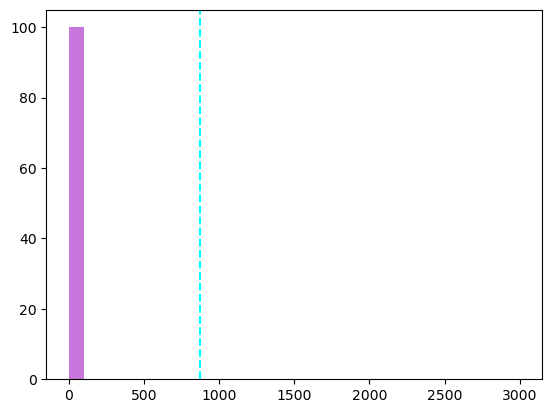

In [42]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),temp_index=2)#,showtrue=False)

In [43]:
ensemble.acceptance_fraction

array([[0.3, 0.3, 0.1, 0.2, 0.3, 0.2, 0.4, 0.3, 0.4, 0.2],
       [0.4, 0.1, 0.4, 0.2, 0.4, 0. , 0.2, 0.3, 0.4, 0.2],
       [0.4, 0.2, 0.1, 0.7, 0.2, 0.3, 0.4, 0.5, 0.6, 0.4]])

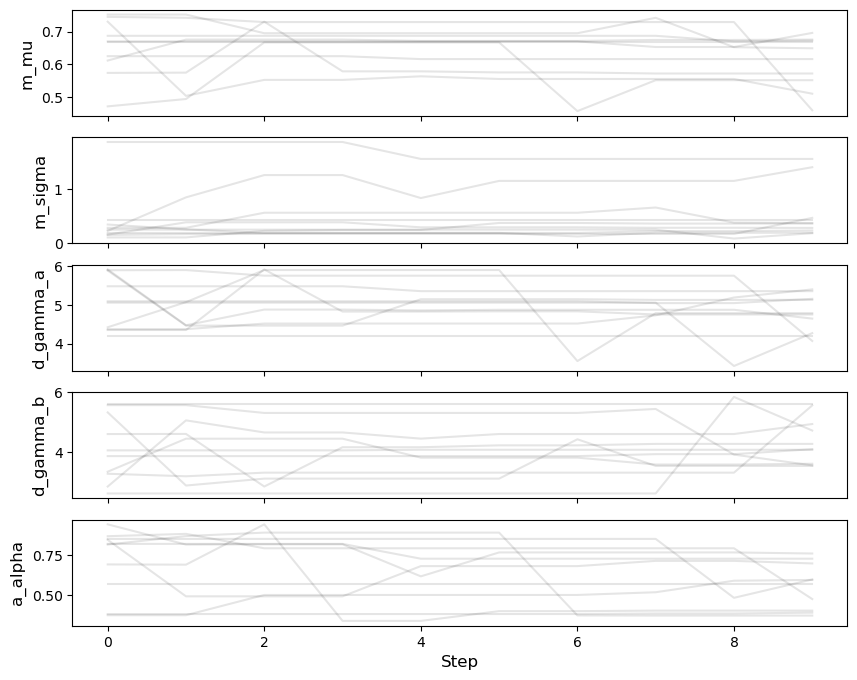

In [44]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

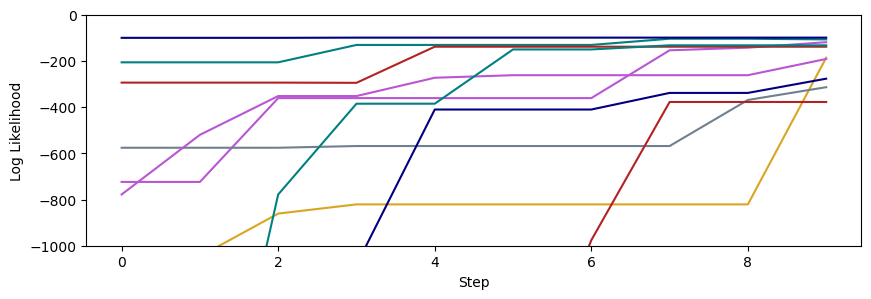

In [45]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,ylim=(-1000,0),temp_index=0)

Starting spectra:

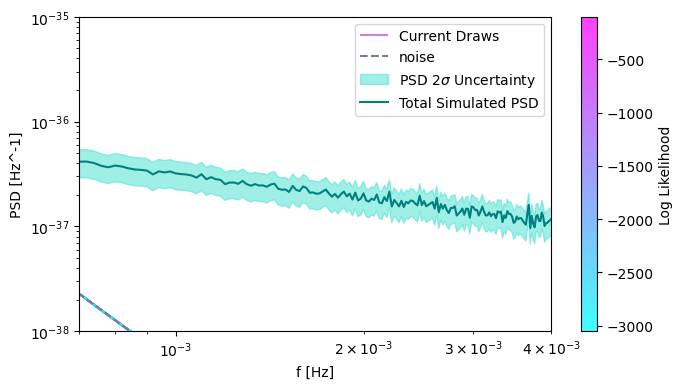

In [46]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=0)

Current spectra:

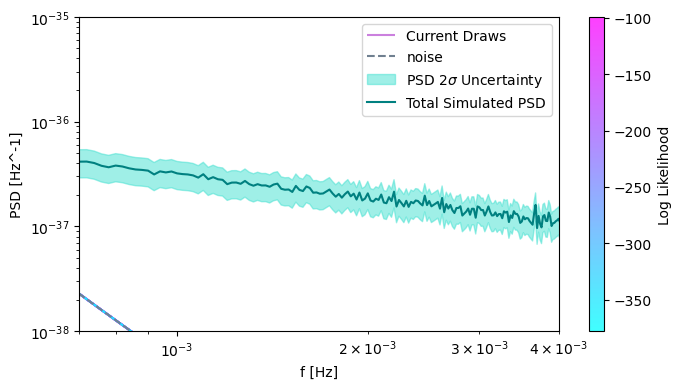

In [47]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

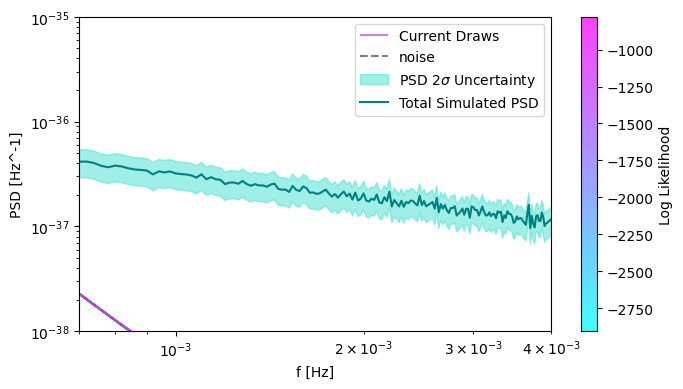

In [48]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=2),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

In [49]:
t1 = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'][:,1,0,:]
t2 = ensemble.get_chain_supplemental(temp_index=1)['model_0']['spectra'][:,1,0,:]
np.sum(t1-t2)

0.0

In [97]:
t1 = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'][:,1,0,:]
t2 = ensemble.get_chain_supplemental(temp_index=1)['model_0']['spectra'][:,1,0,:]
np.sum(t1-t2)

0.0

In [98]:
ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].shape

(100, 10, 1, 244)

In [99]:
t1a = out.branches_supplemental['model_0'][0,1,0,:]['spectra']
t2a = out.branches_supplemental['model_0'][2,1,0,:]['spectra']
np.sum(t1a-t2a)

-5.7104415903199645e-36

In [138]:
t1a = out.branches_supplemental['model_0'][0,1,0,:]['spectra']
t2a = out.branches_supplemental['model_0'][2,1,0,:]['spectra']
np.sum(t1a-t2a)

7.510616564598255e-38

In [139]:
t1 = ensemble.get_chain_supplemental()['model_0']['spectra'][-1,0,1,0,:]
t2 = ensemble.get_chain_supplemental()['model_0']['spectra'][-1,2,1,0,:]
np.sum(t1-t2)

7.510616564598255e-38

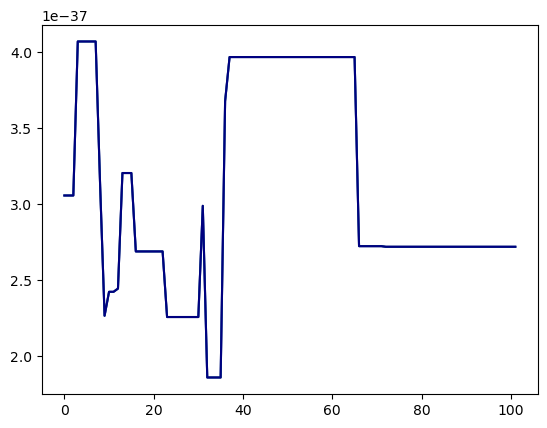

In [133]:
plt.figure()
plt.plot(ensemble.get_chain_supplemental()['model_0']['spectra'][:,:,5,0,50])
plt.show()

In [125]:
# out.branches_supplemental['model_0'].holder

In [121]:
ensemble.get_chain()['model_0'][-1,0,:,0,0] - ensemble.get_chain()['model_0'][-2,0,:,0,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [119]:
t1 = ensemble.get_chain_supplemental()['model_0']['spectra'][-1,0,:,0,:]
t2 = ensemble.get_chain_supplemental()['model_0']['spectra'][-2,0,:,0,:]
np.sum(t1-t2)

0.0

In [43]:
nsteps = 1000
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [3:09:35<00:00, 11.38s/it]


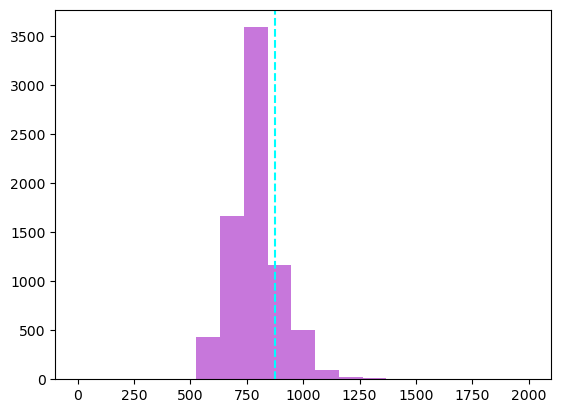

In [52]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,2000,20),discard=100,thin=4)#,showtrue=False)

In [53]:
ensemble.acceptance_fraction

array([[0.00636364, 0.01636364, 0.00909091, 0.01545455, 0.02181818,
        0.00909091, 0.01272727, 0.01545455, 0.01545455, 0.01545455],
       [0.02090909, 0.02181818, 0.02545455, 0.01818182, 0.02454545,
        0.03636364, 0.02181818, 0.02      , 0.03181818, 0.01909091],
       [0.08545455, 0.03818182, 0.03545455, 0.03272727, 0.05727273,
        0.08545455, 0.05636364, 0.04090909, 0.03727273, 0.04454545]])

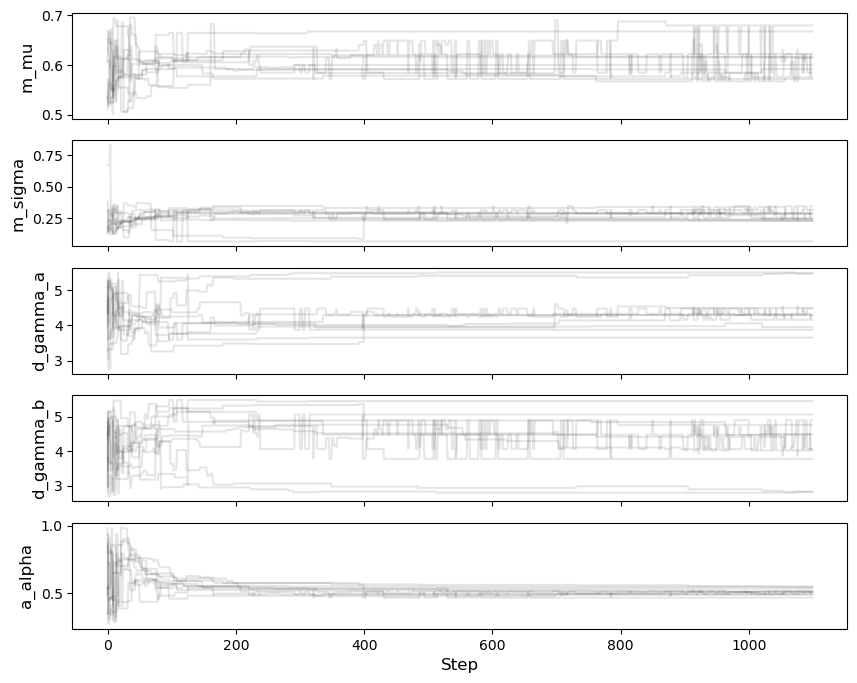

In [94]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=2)

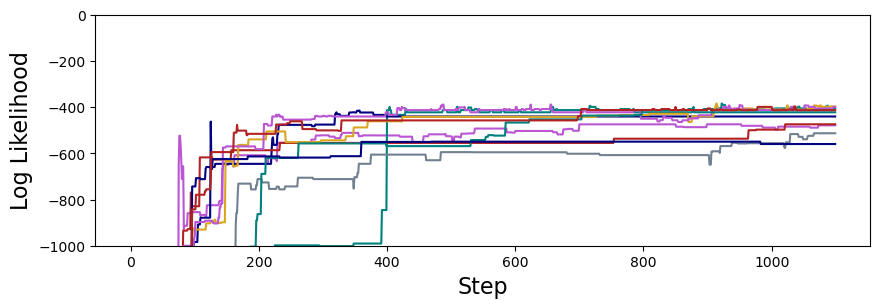

In [97]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,ylim=(-1000,0),temp_index=2)

Where are they now?

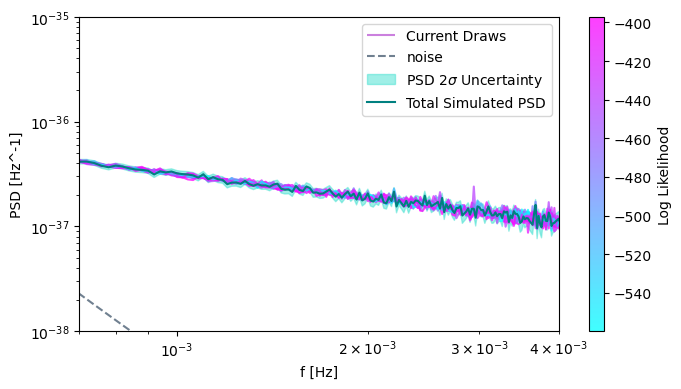

In [68]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=2),xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

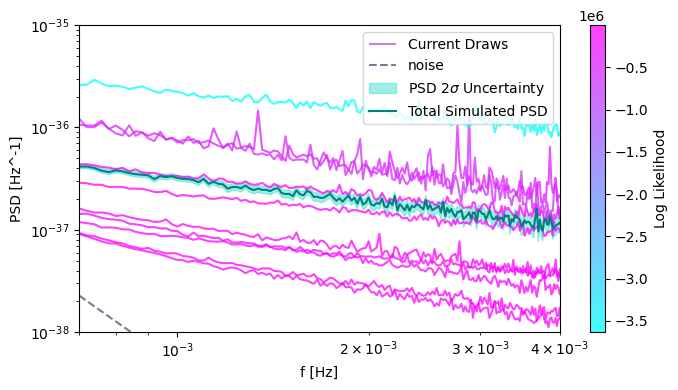

In [58]:
plot_spectra(ensemble,datadict,xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=0)

In [72]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [73]:
truths

array([0.6 , 0.15, 4.  , 4.  , 0.5 ])

In [100]:
samples = ensemble.get_chain(discard=50,temp_index=2,thin=1)['model_0'].reshape(-1,ndim)

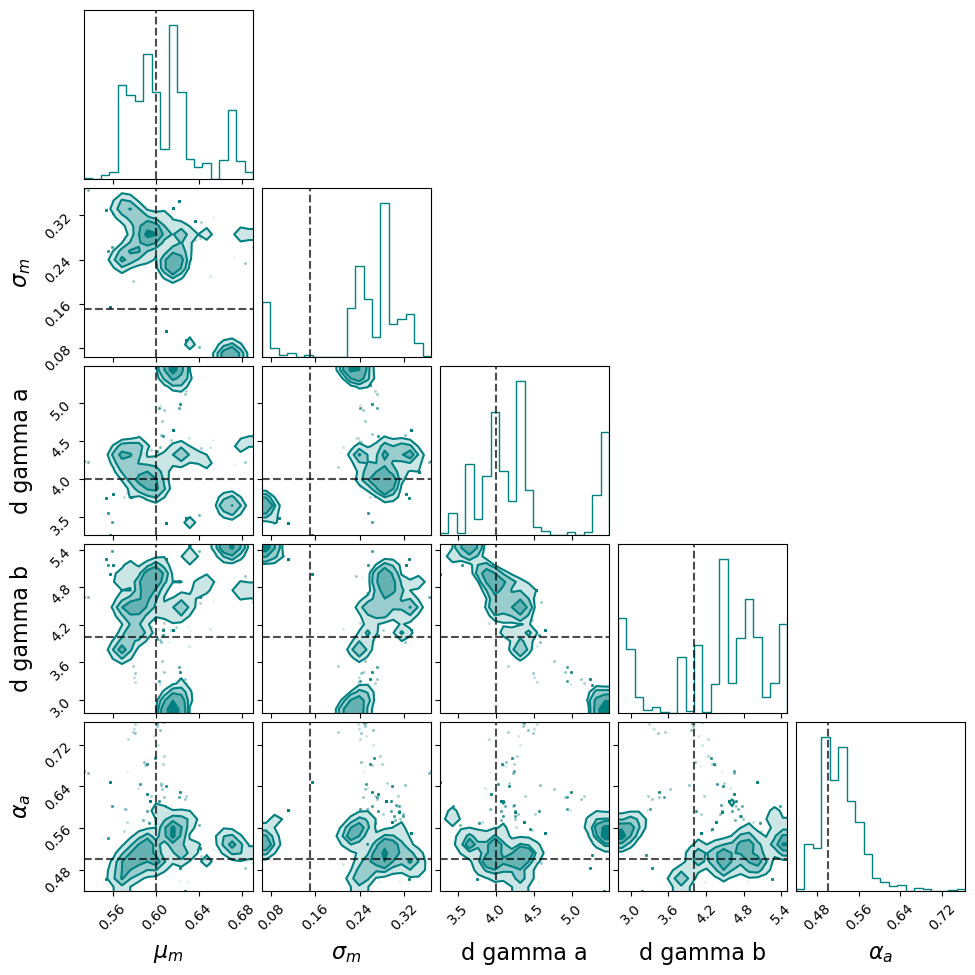

In [101]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [59]:
nsteps = 100
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:19<00:00,  3.80s/it]


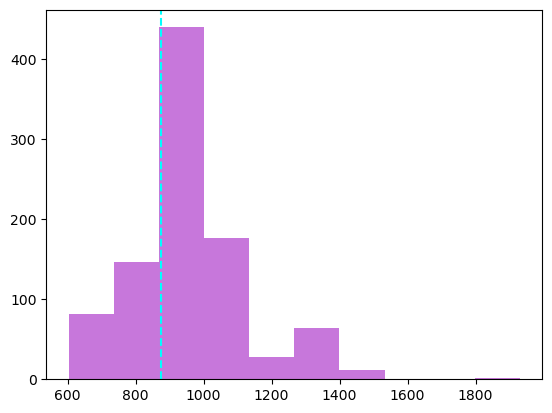

In [67]:
plot_Nres_hist(ensemble,datadict,discard=10)

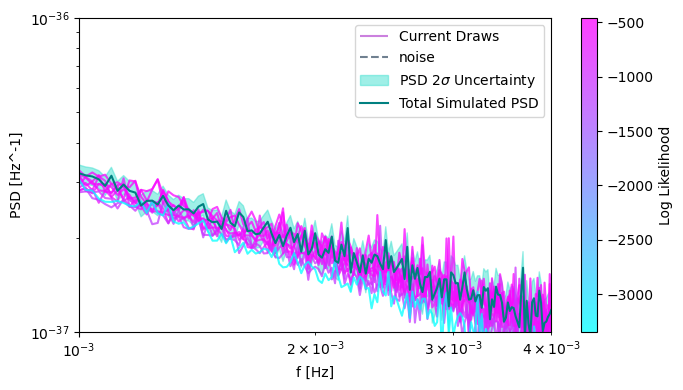

In [61]:
plot_spectra(ensemble,datadict,xlim=(1e-3,4e-3),ylim=(1e-37,1e-36))

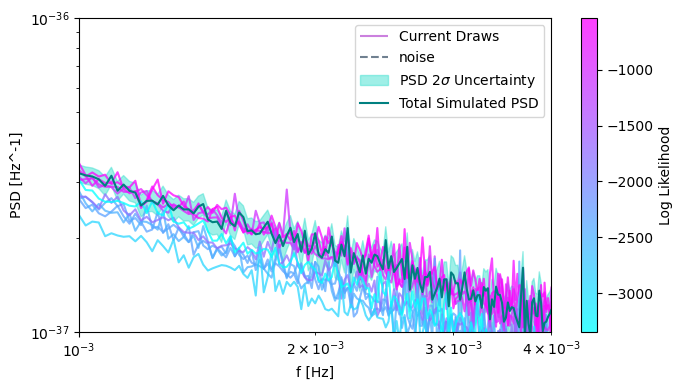

In [62]:
plot_spectra(ensemble,datadict,xlim=(1e-3,4e-3),ylim=(1e-37,1e-36),iteration=50)

In [68]:
ensemble.acceptance_fraction

array([[0.06666667, 0.23809524, 0.0952381 , 0.16190476, 0.22857143,
        0.17142857, 0.04761905, 0.19047619, 0.23809524, 0.1047619 ]])

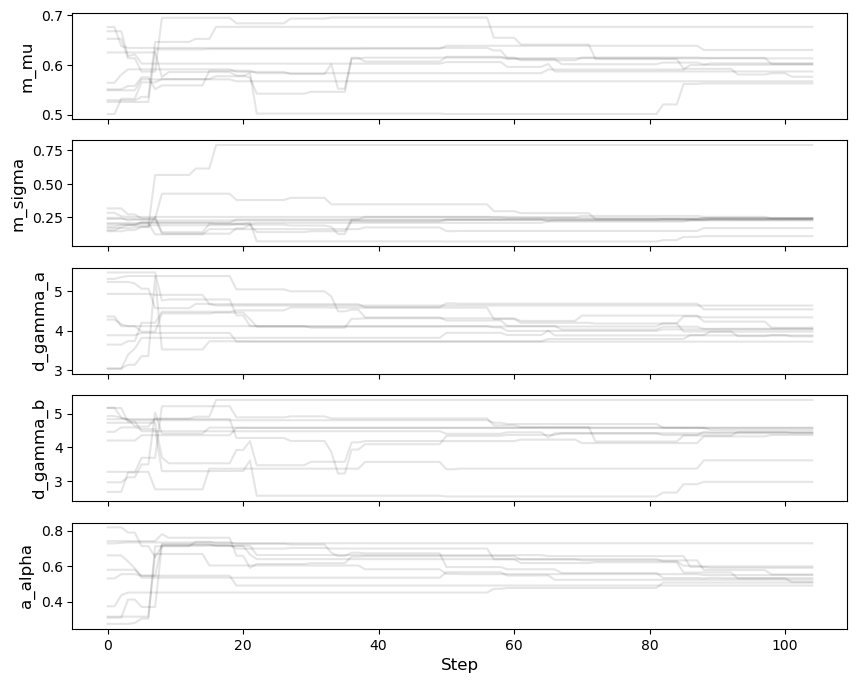

In [69]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names)

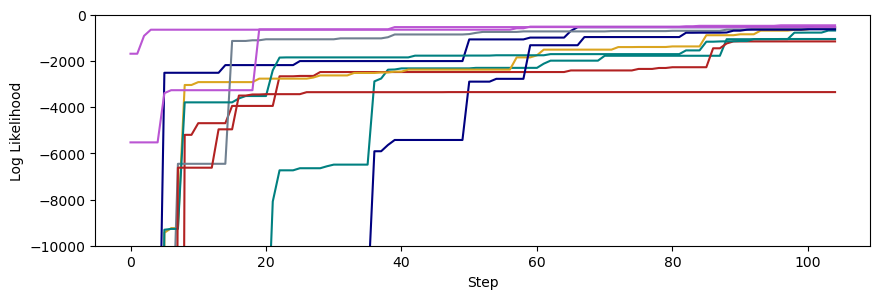

In [70]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,ylim=(-1e4,0))

In [71]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [72]:
truths

array([0.6 , 0.15, 4.  , 4.  , 0.5 ])

In [77]:
samples = ensemble.get_chain(discard=50)['model_0'].reshape(-1, ndim)

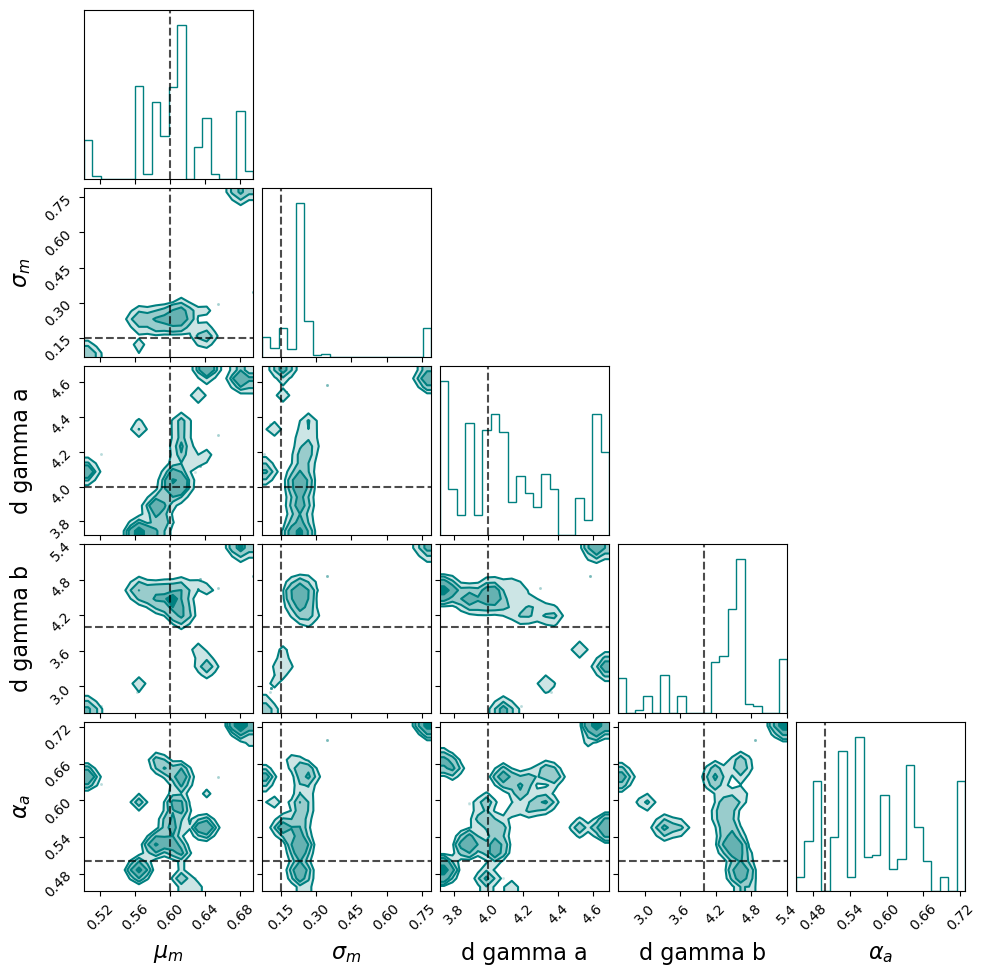

In [78]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [79]:
nsteps = 1000
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:05:55<00:00,  3.96s/it]


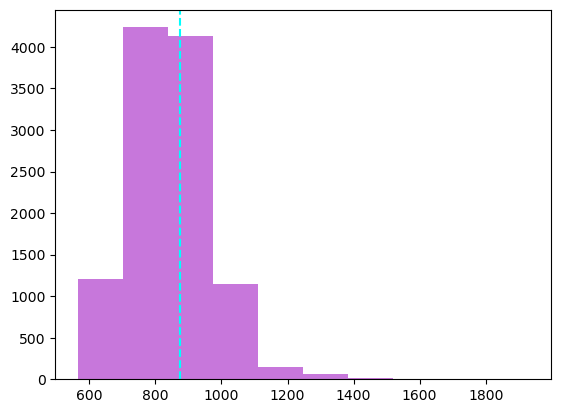

In [80]:
plot_Nres_hist(ensemble,datadict,discard=10)

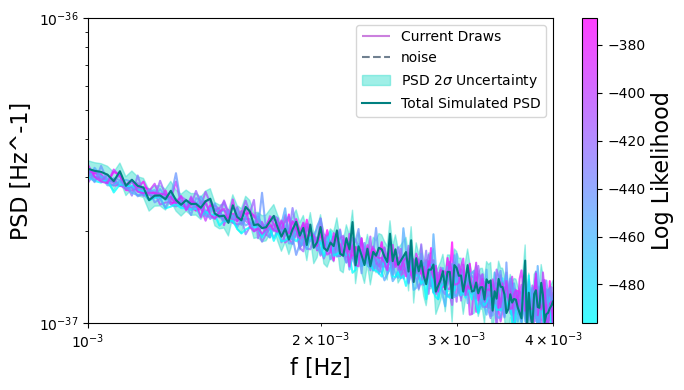

In [81]:
plot_spectra(ensemble,datadict,xlim=(1e-3,4e-3),ylim=(1e-37,1e-36))

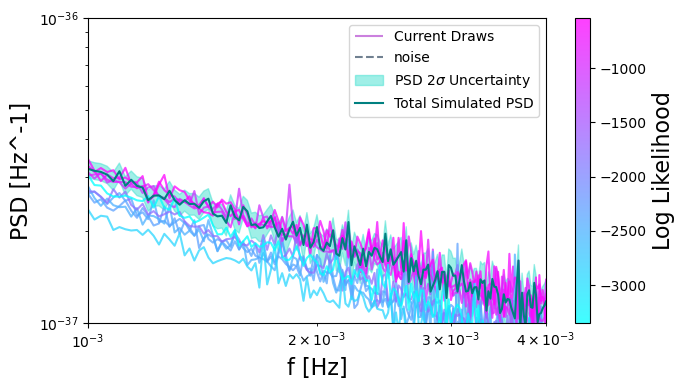

In [82]:
plot_spectra(ensemble,datadict,xlim=(1e-3,4e-3),ylim=(1e-37,1e-36),iteration=50)

In [83]:
ensemble.acceptance_fraction

array([[0.01085973, 0.03438914, 0.01538462, 0.03076923, 0.02443439,
        0.02352941, 0.0081448 , 0.02986425, 0.02714932, 0.02262443]])

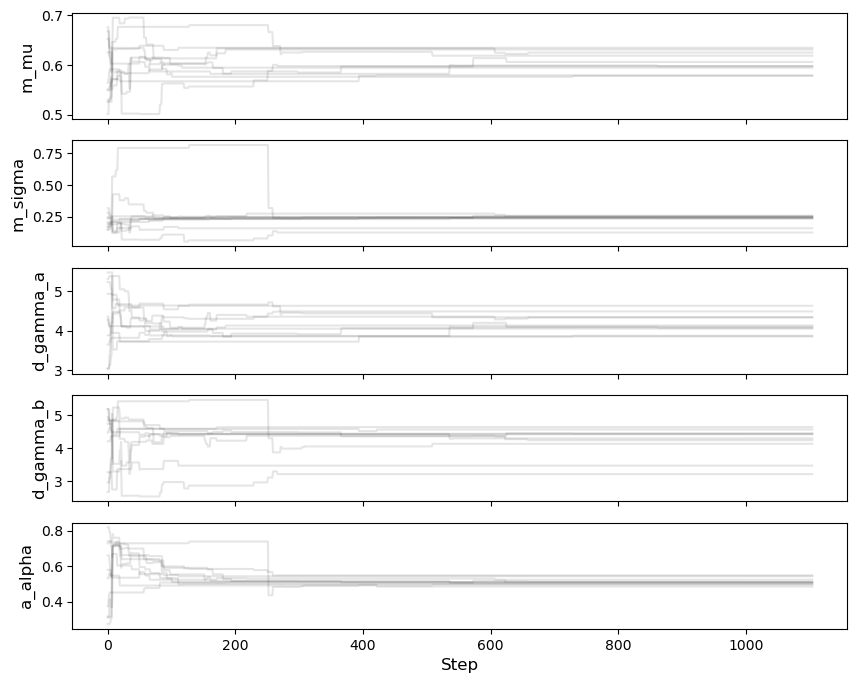

In [84]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names)

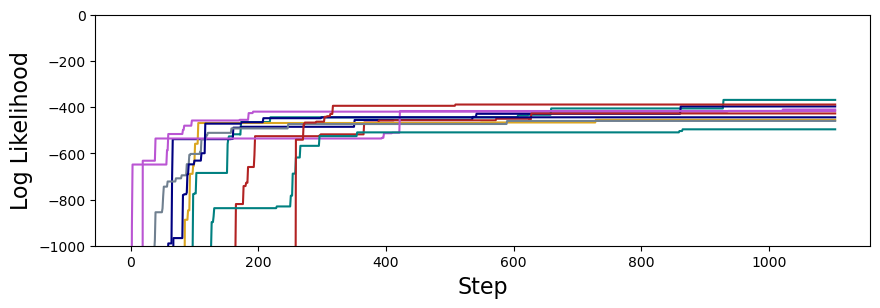

In [92]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,ylim=(-1000,0))

In [86]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [87]:
truths

array([0.6 , 0.15, 4.  , 4.  , 0.5 ])

In [97]:
samples = ensemble.get_chain(discard=500,)['model_0'].reshape(-1, ndim)

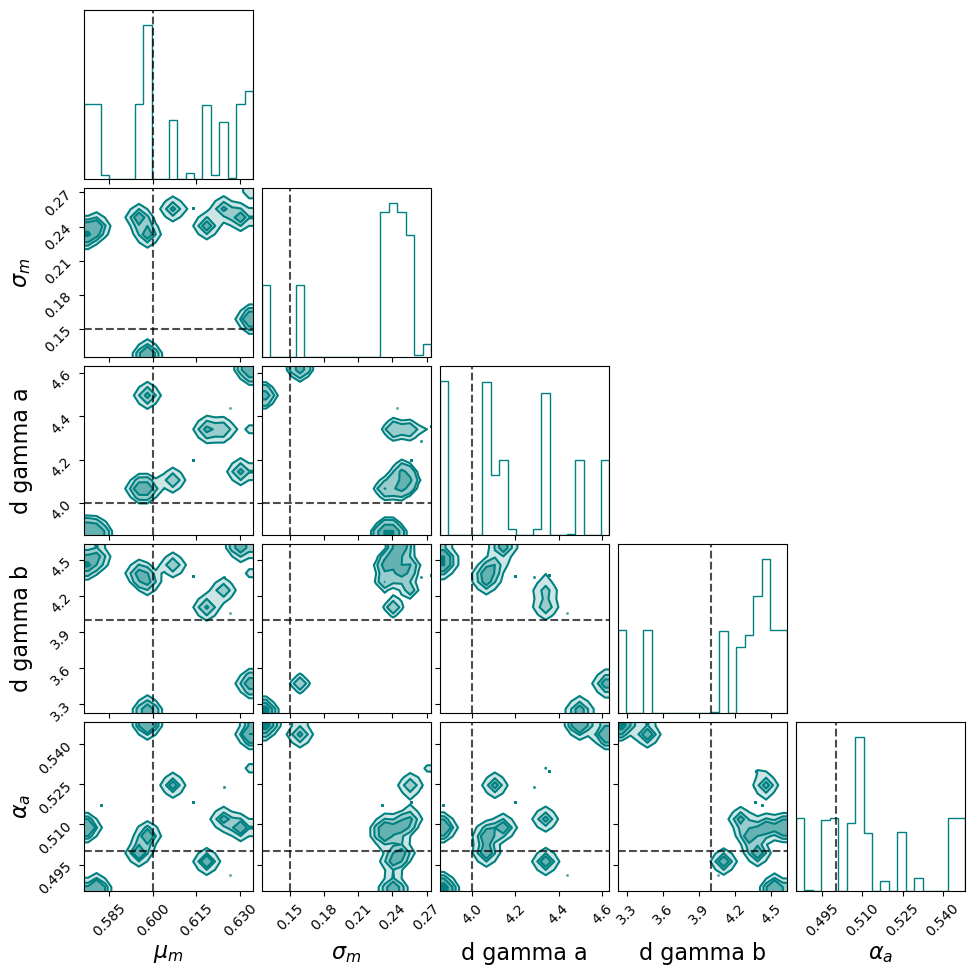

In [98]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )